# **Step1. 상품 리뷰 감성 분류**

**미션 : 리뷰마다 긍/부정 감성분석하기**
1) 목표 : 리뷰를 긍, 부정으로 분류하는 모델 생성
사전학습 모델을 파인 튜닝하여 모델 성능 높이기
2) 절차
    * 데이터 전처리
        - 긍/부정 분류를 위한 데이터셋 구성
        - 데이터 불균형 문제 해결하기
    * 사전학습 모델 파인 튜닝 : klue/bert-base 사용 권장
3) 최소 4가지 이상의 실험을 구성하고 수행하고 성능 비교
    * 학습 + 검증 데이터 : 10만 건 중 일부를 샘플링해서 수행.
    * 모델링 : 일반 파인튜닝, LoRA 파인튜닝 적용
    * 하이퍼파라미터 조정


## 1.환경준비

### (1) 라이브러리 설치 및 로딩

* 설치 후 세션 다시 시작

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import LabelEncoder

from peft import get_peft_model, LoraConfig, TaskType

from warnings import filterwarnings
FutureWarning
filterwarnings('ignore')

c:\Users\USER\anaconda3\envs\aivle_pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# (Jupyter) 시각화 한글폰트 설정을 위해 아래 코드를 실행하세요.
plt.rc('font', family='Malgun Gothic')
sns.set(font="Malgun Gothic",#"NanumGothicCoding",
        rc={"axes.unicode_minus":False}, # 마이너스 부호 깨짐 현상 해결
        style='darkgrid')

* 함수 생성

In [3]:
# 검증셋 평가 함수
def evaluate(val_ds, model, device, tokenizer):
    # 입력 데이터셋 토크나이징 (attention_mask 포함)
    inputs = tokenizer(list(val_ds['text']), return_tensors="pt", padding=True,
                       truncation=True, max_length=128
    )
    inputs = {key: value.to(device) for key, value in inputs.items()}  # 입력 텐서를 동일한 디바이스로 이동

    # 모델을 지정된 디바이스로 이동
    model = model.to(device)

    with torch.no_grad():  # 평가 과정에서 기울기 계산 비활성화
        outputs = model(**inputs)  # attention_mask를 포함해 입력

    # 예측 및 확률 계산
    probabilities = outputs.logits.softmax(dim=1)

    # probabilities가 GPU에 있을 경우에만 CPU로 이동
    if probabilities.is_cuda:
        probabilities = probabilities.cpu().detach().numpy()
    else:
        probabilities = probabilities.detach().numpy()

    pred = np.argmax(probabilities, axis=1)

    # GPU 메모리에서 필요 없는 텐서 제거 및 캐시 정리
    del inputs
    torch.cuda.empty_cache()

    return pred, probabilities

In [4]:
def predict(text, model, tokenizer):
    # 모델을 CPU로 이동
    model = model.to("cpu")

    # 입력 문장 토크나이징 → CPU 텐서로 생성
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # 모델 예측 (no_grad로 메모리 절약)
    with torch.no_grad():
        outputs = model(**inputs)

    # 확률 계산
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1)

    # 예측 클래스
    pred = torch.argmax(probabilities, dim=-1).item()

    return pred, probabilities


### (2) GPU 설정
* GPU 사용을 위한 설정

In [5]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.데이터 준비① : 데이터 구조 만들기
* 아래와 같은 형태로 데이터 셋을 준비합니다.
    * 하나의 리뷰 문장에 하나의 긍/부정 값 지정
    * 리뷰별 label의 평균 값 >= 0.5 ➔ 긍정(1)

* 데이터 불균형을 확인하고 조치합니다.

### (1) 데이터 불러오기
* 제공 받은 'data.csv' 파일을 불러 옵니다.

In [6]:
path = './data/'
df = pd.read_csv(path + 'data.csv')

### (2) 데이터 구조 만들기

* 다음과 같은 형태로 리뷰별 데이터 구조를 만듭니다.

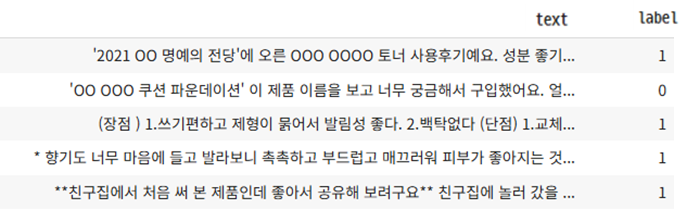

In [7]:
df = df.drop_duplicates(subset=['text'], keep='first')

df = df.drop(columns=['aspect'])

display(df.head())
df.info()

,text,label
0,유통기한도 넉넉하고 구성도 많아서 선물 하기 좋네요. 만족합니다.,1
2,스틱 제형이라 바르기 좋고 보습력도 좋아요. 무엇보다 손에 안 묻히고 바를 수 있어...,1
6,잘 사용하고 있어요. 보습력도 좋고 향도 좋아서 잘 사용합니다. 용량도 커서 부담없...,1
9,자주 많이 손을 씻는 편인데 부담 없이 편하게 쓰기 좋습니다. 보습력이 엄청 많이 ...,0
13,발바닥이 예전 같지 않다는 걸 알고 구입했습니다. 풋 크림을 발라야겠다는 생각했습니...,1


<class 'pandas.core.frame.DataFrame'>
Index: 39495 entries, 0 to 107084
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    39495 non-null  object
 1   label   39495 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 925.7+ KB


### (3) 데이터 불균형 해결하기

* label의 분포 확인하기

In [8]:
display(df['label'].value_counts())
df['label'].value_counts(normalize=True)

label
1    27891
0    11604
Name: count, dtype: int64

label
1    0.706191
0    0.293809
Name: proportion, dtype: float64

* label이 0과 1인 인 경우 각각 샘플링 2000건씩
    * 더 많이 할 수도 있지만 학습 시간을 고려


In [9]:
# 데이터 샘플링
size = 2000

df_pos = df[df['label'] == 1].sample(n=size, random_state=42)
df_neg = df[df['label'] == 0].sample(n=size, random_state=42)

df_balanced = pd.concat([df_pos, df_neg])
df_balanced = df_balanced.sample(frac=1, random_state=42)
df_balanced = df_balanced.reset_index(drop=True)

In [10]:
# 데이터 분포 다시 확인
display(df_balanced['label'].value_counts())
df_balanced['label'].value_counts(normalize=True)

label
1    2000
0    2000
Name: count, dtype: int64

label
1    0.5
0    0.5
Name: proportion, dtype: float64

## 3.데이터 준비② : 데이터 전처리

### (1) Dataset 만들기 : train, val
* train_test_split 함수 이용

In [11]:
from sklearn.model_selection import train_test_split

train, val = train_test_split(df_balanced, test_size=0.2, random_state=42)

* 텐서 데이터셋 만들기

In [12]:
train_ts = Dataset.from_pandas(train) 
val_ts = Dataset.from_pandas(val)

### (2) 토크나이징
* 모델 : "klue/bert-base"

In [13]:
# 모델과 토크나이저 불러오기
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [14]:
# 토큰화 함수 생성 및 작업
def preprocess_function(data):
    return tokenizer(data['text'], truncation=True, padding=True)

train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

train_ts.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_ts.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map: 100%|██████████| 800/800 [00:00<00:00, 6349.14 examples/s]


## 4.Fine-Tuning ①
* 일반 파인 튜닝 수행

### (1) 사전학습 모델 준비

In [15]:
# 모델 로드
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### (2) 학습 설정

In [16]:
# TrainingArguments 설정
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,               # 작은 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to=None,
    fp16=True
)

In [17]:
# Trainer 설정
trainer = Trainer(
    model=model,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

### (3) 학습

In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.284700,0.287378
2,0.193500,0.255002
3,0.089600,0.287243
4,0.042500,0.371549
5,0.036300,0.392320


TrainOutput(global_step=500, training_loss=0.1520318219065666, metrics={'train_runtime': 249.6089, 'train_samples_per_second': 64.1, 'train_steps_per_second': 2.003, 'total_flos': 2663999435520000.0, 'train_loss': 0.1520318219065666, 'epoch': 5.0})

### (4) 모델 검증평가

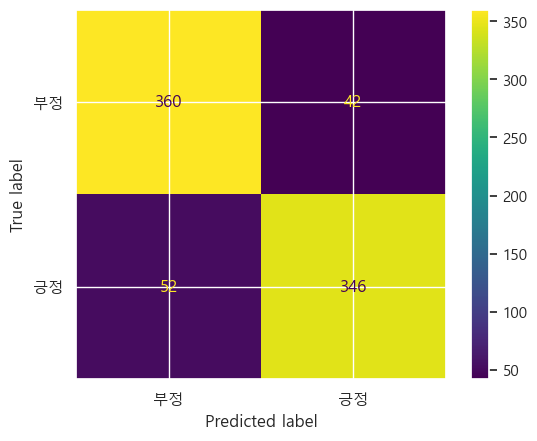

              precision    recall  f1-score   support

          부정       0.87      0.90      0.88       402
          긍정       0.89      0.87      0.88       398

    accuracy                           0.88       800
   macro avg       0.88      0.88      0.88       800
weighted avg       0.88      0.88      0.88       800



In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

label_list = ['부정', '긍정']
val_df = val_ts.to_pandas()
pred, prob = evaluate(val, model, device, tokenizer)

disp = ConfusionMatrixDisplay(confusion_matrix(val_ts['label'], pred), display_labels = label_list)
disp.plot()
plt.show()

print(classification_report(val_ts['label'], pred, target_names = label_list))

In [ ]:
text = "배송이 빠르고 제품 상태도 좋아요!"
pred, prob = predict(text, model, tokenizer)

print(f"문장: {text}")
print(f"예측 라벨: {'긍정' if pred == 1 else '부정'}")
print(f"확률: {prob}")

문장: 배송이 너무 느려요
예측 라벨: 부정
확률: tensor([[0.9706, 0.0294]])


In [35]:
trainer.save_model("./saved_binary_model")
tokenizer.save_pretrained("./saved_binary_model")

('./saved_binary_model\\tokenizer_config.json',
 './saved_binary_model\\special_tokens_map.json',
 './saved_binary_model\\vocab.txt',
 './saved_binary_model\\added_tokens.json',
 './saved_binary_model\\tokenizer.json')

## 5.Fine-Tuning②
* LoRA(Low-Rank Adaptation)

### (1) 사전학습 모델 준비
* 위에서 적용한 내용

In [14]:
# 모델 로드
model_name = "klue/bert-base"
num_labels = 2
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 사전 학습된 모델 로드 (전체 파라미터는 그대로)
base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at klue/bert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
# 토큰화 함수 생성 및 작업
def preprocess_function(data):
    return tokenizer(data['text'], truncation=True, padding=True)

train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

Map: 100%|██████████| 800/800 [00:00<00:00, 6060.65 examples/s]


### (2) LoRA 구성

In [17]:
# LoRA 구성 정의
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # 시퀀스 분류
    r=8,                         # 랭크 값 (작을수록 파라미터 적음)
    lora_alpha=32,               # 너무 작으면 학습 효과 약하고, 너무 크면 발산 위험
    lora_dropout=0.1,
    target_modules=["query", "value"],  
    bias="none"                 # bias는 학습하지 않음
)

# LoRA 적용 (일부 레이어만 학습)
model = get_peft_model(base_model, lora_config)

### (3) 학습

In [18]:
# TrainingArguments 설정
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-4,               # 작은 학습률
    per_device_train_batch_size = 8,   # 학습 배치 사이즈
    per_device_eval_batch_size = 16,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to=None,
    fp16=True
)

# Trainer 설정 (compute_metrics, callbacks 등 필요 시 추가 가능)
trainer = Trainer(
    model=model,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

In [19]:
# 학습 시작
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.288500,0.342042
2,0.243600,0.289409
3,0.200900,0.338292
4,0.121700,0.341155
5,0.011600,0.360909


TrainOutput(global_step=2000, training_loss=0.22819400386512279, metrics={'train_runtime': 179.8429, 'train_samples_per_second': 88.967, 'train_steps_per_second': 11.121, 'total_flos': 2661454747096320.0, 'train_loss': 0.22819400386512279, 'epoch': 5.0})

### (4) 모델 검증평가

In [20]:
text = "배송이 빠르고 제품 상태도 좋아요!"
pred, prob = predict(text, model, tokenizer)

print(f"문장: {text}")
print(f"예측 라벨: {'긍정' if pred == 1 else '부정'}")
print(f"확률: {prob}")

문장: 배송이 빠르고 제품 상태도 좋아요!
예측 라벨: 긍정
확률: tensor([[0.0013, 0.9987]])


In [21]:
pred, prob = evaluate(val_ts, model, device, tokenizer)

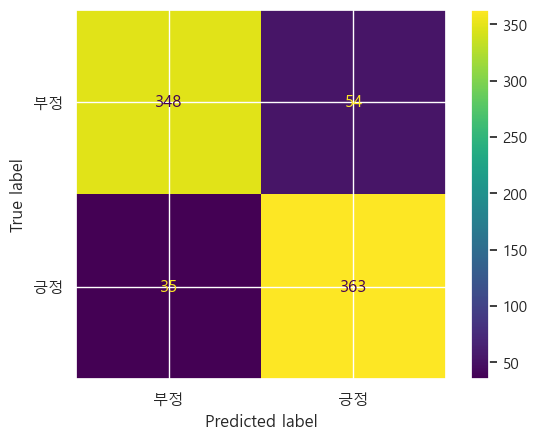

              precision    recall  f1-score   support

          부정       0.91      0.87      0.89       402
          긍정       0.87      0.91      0.89       398

    accuracy                           0.89       800
   macro avg       0.89      0.89      0.89       800
weighted avg       0.89      0.89      0.89       800



In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

label_list = ['부정', '긍정']
disp = ConfusionMatrixDisplay(confusion_matrix(val_ts['label'], pred), display_labels = label_list)
disp.plot()
plt.show()

print(classification_report(val_ts['label'], pred, target_names = label_list))